### BaggingClassifier - Wind dataset

#### Step 1: import package

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

#### Step 2: Load data

In [16]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data',
               header=None)
df_wine.columns = ['Class label', 'Alcohol',
                    'Malic acid', 'Ash',
                    'Alcalinity of ash',
                    'Magnesium', 'Total phenols',
                    'Flavanoids', 'Nonflavanoid phenols',
                    'Proanthocyanins',
                    'Color intensity', 'Hue',
                    'OD280/OD315 of diluted wines',
                    'Proline']

# only consider Wine classes 2 and 3
df_wine = df_wine[df_wine['Class label'] != 1]
y = df_wine['Class label'].values

X = df_wine[['Alcohol','OD280/OD315 of diluted wines']].values



# categorize label y, and split data to train and test
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

#### Step 3: Applying the model

In [17]:
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    random_state=1
)

bag = BaggingClassifier(
    estimator=tree,
    n_estimators=100,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=1

)

#### Step 4: Evaluation

In [18]:
# tree model
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'train accuracy: {tree_train:.4f}; test accuracy: {tree_test:.4f}')

train accuracy: 1.0000; test accuracy: 0.8333


In [19]:
# bagging classifier model
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)
print(f'train accuracy: {bag_train:.4f}; test accuracy: {bag_test:.4f}')

train accuracy: 1.0000; test accuracy: 0.9167


#### Step 5: Decision Boundary

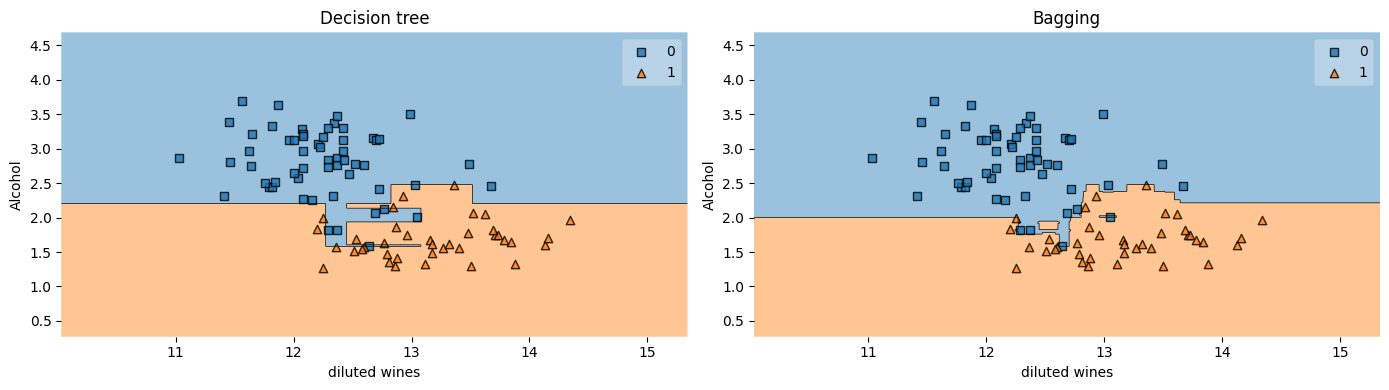

In [24]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
plot_decision_regions(X_train, y_train, clf=tree, ax=axes[0])
plot_decision_regions(X_train, y_train, clf=bag, ax=axes[1])

axes[0].set_title('Decision tree')
axes[0].set_ylabel('Alcohol')
axes[0].set_xlabel('diluted wines')

axes[1].set_title('Bagging')
axes[1].set_ylabel('Alcohol')
axes[1].set_xlabel('diluted wines')

plt.tight_layout()
plt.show()